### Data Description
The dataset contains hourly bike rental counts from a bike-sharing system.  

**Features:**
- `instant`: Record index  
- `dteday`: Date  
- `season`: Season (1: spring, 2: summer, 3: fall, 4: winter)  
- `yr`: Year (0: 2011, 1: 2012)  
- `mnth`: Month (1 to 12)  
- `hr`: Hour (0 to 23)  
- `holiday`: Whether the day is a holiday or not  
- `weekday`: Day of the week  
- `workingday`: 1 if the day is neither a weekend nor a holiday, 0 otherwise  
- `weathersit`: Weather situation  
  - 1: Clear, Few clouds, Partly cloudy  
  - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist  
  - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds  
  - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog  
- `temp`: Normalized temperature (Celsius)  
- `atemp`: Normalized feeling temperature (Celsius)  
- `hum`: Normalized humidity (0–1)  
- `windspeed`: Normalized wind speed (0–1)  
- `casual`: Count of casual users  
- `registered`: Count of registered users  
- `cnt`: Total rental bikes (casual + registered) 

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [58]:
df_bike = pd.read_csv("Bike.csv")

In [59]:
# Rename the ’cnt’ column to ’cnt_rental_bike’ for clarity
df_bike.rename(columns={'cnt':'cnt_rental_bike'}, inplace=True)

1. What are the first few rows of your loaded DataFrame?

In [60]:
df_bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt_rental_bike
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


1.2 How many rows and columns does it have?

In [61]:
df_bike.shape

(17379, 17)

1.3 What are the data types for each column?

In [62]:
df_bike.dtypes

instant              int64
dteday              object
season               int64
yr                   int64
mnth                 int64
hr                   int64
holiday              int64
weekday              int64
workingday           int64
weathersit           int64
temp               float64
atemp              float64
hum                float64
windspeed          float64
casual               int64
registered           int64
cnt_rental_bike      int64
dtype: object

2. Are there missing values in your dataset? If so, which columns are affected?

In [63]:
df_bike.isnull().sum()

instant            0
dteday             0
season             0
yr                 0
mnth               0
hr                 0
holiday            0
weekday            0
workingday         0
weathersit         0
temp               0
atemp              0
hum                0
windspeed          0
casual             0
registered         0
cnt_rental_bike    0
dtype: int64

NO, there are no missing values 

3. Are there duplicate rows? NO

In [64]:
df_bike.duplicated().sum()

np.int64(0)

4. The dataset has several columns related to date and time. Create a new
column, datetime, that combines the date and time information. What
is the appropriate data type for this new column?

In [65]:
df_bike['datetime'] = pd.to_datetime(df_bike['dteday']) + pd.to_timedelta(df_bike['hr'], unit='h')
df_bike[['dteday', 'hr', 'datetime']].head()

,dteday,hr,datetime
0,2011-01-01,0,2011-01-01 00:00:00
1,2011-01-01,1,2011-01-01 01:00:00
2,2011-01-01,2,2011-01-01 02:00:00
3,2011-01-01,3,2011-01-01 03:00:00
4,2011-01-01,4,2011-01-01 04:00:00


5. Use the function describe() from pandas to analyze basic statistics of
your data set (no need to use print(), pandas prints a structured table
automatically).

In [66]:
df_bike.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt_rental_bike,datetime
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088,2012-01-02 15:41:22.858622464
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2011-01-01 00:00:00
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000,2011-07-04 22:30:00
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000,2012-01-02 21:00:00
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000,2012-07-02 06:30:00
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000,2012-12-31 23:00:00
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599,NaN


6. What is the total number of bike rentals? What are the average, minimum,
and maximum rental counts?

In [67]:
print(df_bike['cnt_rental_bike'].sum())
print(df_bike['cnt_rental_bike'].mean())
print(df_bike['cnt_rental_bike'].min())
print(df_bike['cnt_rental_bike'].max())

3292679
189.46308763450142
1
977


7. Visualize the distribution of bike rentals between different seasons. Which
season has the highest average rental count?

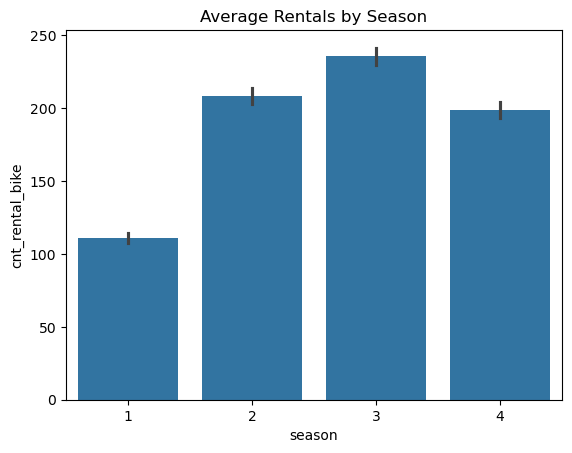

season
1    111.114569
2    208.344069
3    236.016237
4    198.868856
Name: cnt_rental_bike, dtype: float64

In [68]:
season_avg = df_bike.groupby('season')['cnt_rental_bike'].mean()
sns.barplot(x='season', y='cnt_rental_bike', data=df_bike, estimator=np.mean)
plt.title("Average Rentals by Season")
plt.show()
season_avg

8. Compare the rental numbers for casual users versus registered users. How
do their average daily usage patterns differ?

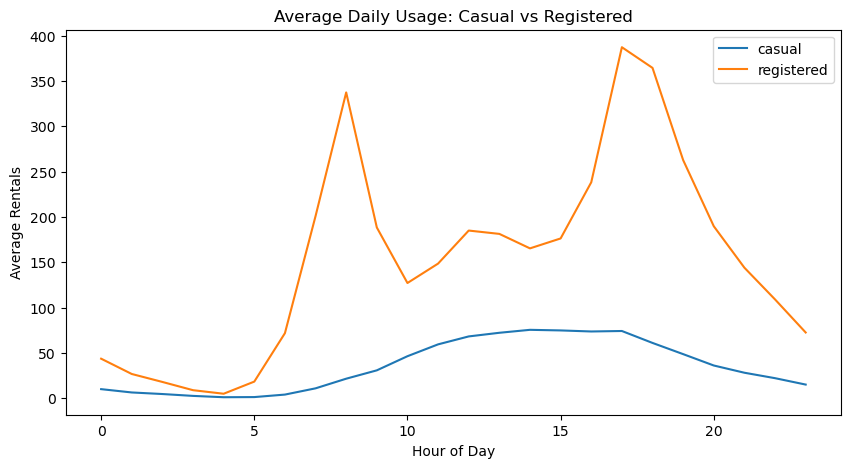

,casual,registered
hr,,
0,10.158402,43.739669
1,6.504144,26.871547
2,4.772028,18.097902
3,2.715925,9.011478
4,1.253945,5.098996


In [69]:
hourly_usage = df_bike.groupby('hr')[['casual', 'registered']].mean()

hourly_usage.plot(figsize=(10,5))
plt.title("Average Daily Usage: Casual vs Registered")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.show()

hourly_usage.head()

Usage of registered is often in the morning and evening, usage of casual in the afternoon. But registerd users are always more than casual users.

9. What are the unique values of weathersit column? Replace them by
descriptive labels:

• 1: ’clear’

• 2: ’cloudy’

• 3: ’light rain’

• 4: ’heavy rain’

In [70]:
df_bike['weathersit'].unique()

array([1, 2, 3, 4])

In [71]:
weather_map = {
    1: 'clear',
    2: 'cloudy',
    3: 'light rain',
    4: 'heavy rain'
}

df_bike['weathersit'] = df_bike['weathersit'].map(weather_map)

In [72]:
df_bike['weathersit'].unique()

array(['clear', 'cloudy', 'light rain', 'heavy rain'], dtype=object)

10. What is the data type of the weathersit column? Object

In [73]:
df_bike['weathersit'].dtype

dtype('O')

11. Visualize the relationship between weather conditions (weathersit) and
the number of rentals. Which weather situation corresponds to the highest
number of rentals on average? Does it make sense?

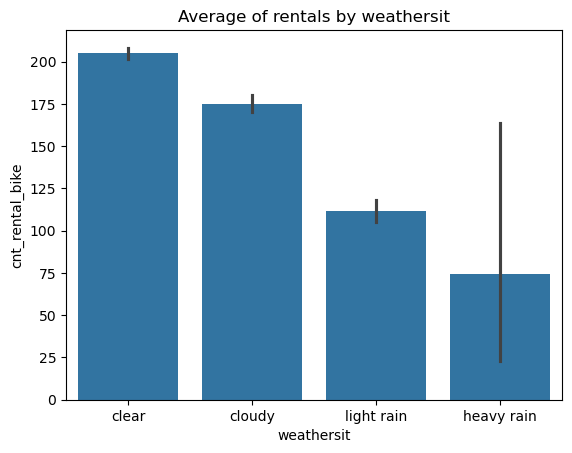

weathersit
clear         204.869272
cloudy        175.165493
heavy rain     74.333333
light rain    111.579281
Name: cnt_rental_bike, dtype: float64

In [74]:
avg_cnt_rental_bike = df_bike.groupby('weathersit')['cnt_rental_bike'].mean()
sns.barplot(x='weathersit', y='cnt_rental_bike', data=df_bike, estimator=np.mean)
plt.title("Average of rentals by weathersit")
plt.show()
avg_cnt_rental_bike

The highest number of rentals on average is in clear weather. It makes sense, because it rains, it is not best condition to ride a bike, but there are users who still rent.

12. Use the function OneHotEncoder from Scikitlearn to encode your column.

In [75]:
encoder = OneHotEncoder(sparse_output=False, drop=None)
encoded = encoder.fit_transform(df_bike[['weathersit']])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['weathersit']))
encoded_df.head()

,weathersit_clear,weathersit_cloudy,weathersit_heavy rain,weathersit_light rain
0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0


13. Consider the advantages and disadvantages of using one-hot encoding on
a categorical variable. Does your answer depend on whether the variable
is nominal (no order, like weather) or ordinal (has a natural order, like a
rating scale)?

Advantages: no assumption of order, good for categorical data.

Disadvantages: increases dimensionality (many columns), leads to multicollinearity if used with linear models.

Nominal (unordered, like weather): One-hot encoding is correct.

Ordinal (ordered, like rating 1–5): Better to use ordinal encoding or treat as numeric.

14. What can you say about the linear dependence of the columns produced
by one-hot encoding? What solution exists to avoid this problem? Change
your OneHotEncoder function accordingly.

One-hot encoding creates dummy variable trap (columns sum to 1 → linear dependence).

Solution: drop one category (use drop='first' in encoder).

In [76]:
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(df_bike[['weathersit']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['weathersit']))
encoded_df.head()

,weathersit_cloudy,weathersit_heavy rain,weathersit_light rain
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


15. Repeat the process of encoding using ordinal encoding for a suitable categorical column. Why can we consider that this method is more appropriate
than one-hot encoding?

We can consider Ordinal Encoding more appropriate than One-Hot Encoding in this case because the categories in the weathersit column have a natural order (from clear to heavy rain). Ordinal Encoding preserves this order by assigning increasing numerical values to worsening weather conditions. This way, the model can capture the relationship that as weather gets worse, the number of rentals tends to decrease.

In contrast, One-Hot Encoding would treat all weather categories as unrelated, losing this useful ordinal information.

In [77]:
encoder = OrdinalEncoder()
df_bike['weathersit_encoded'] = encoder.fit_transform(df_bike[['weathersit']])
df_bike[['weathersit','weathersit_encoded']].head(20)

,weathersit,weathersit_encoded
0,clear,0.0
1,clear,0.0
2,clear,0.0
3,clear,0.0
4,clear,0.0
5,cloudy,1.0
6,clear,0.0
7,clear,0.0
8,clear,0.0
9,clear,0.0


16. Choose a numerical feature and normalize it to a range of [0, 1].

In [78]:
scaler = MinMaxScaler()

df_bike['cnt_normalized'] = scaler.fit_transform(df_bike[['cnt_rental_bike']])

df_bike[['cnt_rental_bike', 'cnt_normalized']].head()

,cnt_rental_bike,cnt_normalized
0,16,0.015369
1,40,0.039959
2,32,0.031762
3,13,0.012295
4,1,0.000000


17. Standardize the same feature using standardization.

In [79]:
scaler = StandardScaler()
df_bike['cnt_rental_bike_norm'] = scaler.fit_transform(df_bike[['cnt_rental_bike']])
df_bike[['cnt_rental_bike','cnt_rental_bike_norm']].head()

,cnt_rental_bike,cnt_rental_bike_norm
0,16,-0.956339
1,40,-0.824022
2,32,-0.868128
3,13,-0.972879
4,1,-1.039037


##### 18. Which features would you consider normalizing, and which would you standardize? Justify your choices based on their distributions.

*Normalize (Min-MaxScaling - scale to [0,1]):*
- `cnt_rental_bike`, `casual`, `registered` - these features have a large range and strong positive skewness.  
  Normalization makes their values comparable and reduces the impact of very large numbers.  

*Standardize (z-score Scaling, mean=0, σ=1):*
- Best for features with approximately normal distributions. Ensures that all features are centered and on the same scale, which is important for many linear models and PCA.  

*RobustScaler (robust to outliers):*  
- useful when features contain outliers. Relies on the median and interquartile range, so extreme values have less influence.

*Conclusion:* the choice of scaling method depends on the distribution of the feature.  
- skewed and sparse features -> normalize,  
- “approximately normal” features -> standardize,  
- features with outliers -> use robust scaling.  

#### 3 Conceptual Questions
1. A column with values ’male’, ’female’, ’NaN’ is an example of what type
of data?
• (A) Ordinal

• (B) Nominal

• (C) Continuous

• (D) Numerical

##### *Answer: B, because "male" and "female" are categories with no order*

2. Explain the difference between nominal and ordinal data types. Provide
an example for each that is not from this dataset.

##### *Answer:*
##### *Nominal: Categories that do not have an order.*

##### *Example: {Dog, Cat, Bird}. There is no ranking between them.*

##### *Ordinal: Categories with a meaningful order.*

##### *Example: {Bronze < Silver < Gold}. The values represent ranking, but the “distance” between them is not necessarily equal.* 

3. If two features are perfectly linearly dependent, it means they contain
redundant information for a linear model.

• (A) True

• (B) False

##### *Answer: True, because if two features are perfectly linearly dependent, one can be expressed as a linear combination of the other. This means they provide redundant information for a linear model*

4. Consider a one-hot encoded feature with N categories. If you do not drop
any of the one-hot columns, what is the relationship between the sum of
the values in these N columns and the number of rows?

##### *Answer: For a one-hot encoded feature with N categories, each row will have exactly one "1" and all other values will be 0. So, if you sum across all N columns, the result for each row will always be 1. If we sum over all rows, the total equals the number of rows in the dataset.*

5. Why is it a common practice to drop one of the columns after one-hot
encoding a feature for use in a linear regression model? What is the
statistical term for this issue?

##### *Answer: after one-hot encoding, the sum of all columns equals 1 for each row, which means the columns are perfectly linearly dependent. If we keep all columns in a linear regression model, this causes multicollinearity, making the model unable to compute unique coefficients.Dropping one column removes the redundancy and allows the model to estimate coefficients properly.*

6. You have a dataset with a column representing a country’s rank in a
competition (1st, 2nd, 3rd, etc.). Would you recommend using one-hot
encoding or ordinal encoding for this feature? Justify your choice.

##### *Answer: Ranks have a natural order (1 < 2 < 3). Using ordinal encoding preserves this relationship.Ordinal encoding preserves this order, allowing models to understand that a lower rank is “better” than a higher rank. Using one-hot encoding would lose the order information, treating all ranks as unrelated categories.*

7. Describe a scenario where using one-hot encoding could lead to a significant increase in the dimensionality of your dataset.

##### *Answer: If a categorical feature has a very large number of unique values, one-hot encoding creates a huge number of columns. F.e^: countries (almost 200 categories).*

8. Which of the following scaling methods transforms the data to have a
mean of 0 and a standard deviation of 1?

• (A) Normalization (Min-Max Scaling)

• (B) Standardization

• (C) Log Transformation

• (D) Robust scaling

##### *Answer: B, standardization - z-score scaling*

9. Normalization is generally preferred when the data contains significant
outliers, as it is more robust to them than standardization.

• (A) True

• (B) False

##### *Answer: False, normalization (min-max scaling) is not robust to outliers because extreme values shrink the scale of all other data. Robust scaling is preferred in the presence of outliers*

10. A feature has values {10, 22, 27, 53}. Calculate the normalized values for
this feature using Min-Max scaling.

In [80]:
print((10 - 10)/(53 - 10))
print((22 - 10)/(53 - 10))
print((27 - 10)/(53 - 10))
print((53 - 10)/(53 - 10))

0.0
0.27906976744186046
0.3953488372093023
1.0


In [81]:
df = pd.DataFrame({'value' : [10, 22, 27, 53]})
scaler = MinMaxScaler()
df['value_normalized'] = scaler.fit_transform(df[['value']])
df

,value,value_normalized
0,10,0.000000
1,22,0.279070
2,27,0.395349
3,53,1.000000


11. A feature has a mean (µ) of 50 and a standard deviation (σ) of 10. A
specific data point has a value of 75. Calculate its standardized value
(Z-score).

In [82]:
(75 - 50) / 10

2.5

12. What is the main purpose of scaling features before training a machine
learning model? Name at least two types of models that are particularly
sensitive to the scale of input features.

##### *Answer: To put features on a comparable scale. Prevents features with large values (e.g., income in thousands) from dominating the model.Helps optimization algorithms (like gradient descent) converge faster.*
*Linear/Logistic regression with gradient descent.*
*KNN (K-Nearest Neighbors): distance-based → needs scaled data.*